Hola **Fercho**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para dar una mejor presentación y seguir buenas prácticas en el uso de notebooks te recomiendo que siempre al inicio de los mismos dejes en una celda markdown un título descriptivo del proyecto y una breve introducción del mismo 
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np
from sklearn.cluster import KMeans

In [2]:
gym_churn = pd.read_csv('/datasets/gym_churn_us.csv')

### Verificar datos.

In [3]:
gym_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [4]:
print(gym_churn.head())

   gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   Group_visits  Age  Avg_additional_charges_total  Month_to_end_contract  \
0             1   29                     14.227470                    5.0   
1             1   31                    113.202938                   12.0   
2             0   28                    129.448479                    1.0   
3             1   33                     62.669863                   12.0   
4             0   26                    198.362265                    1.0   

   Lifetime  Avg_class_frequency_total  Avg_class_frequency_current_month  \
0  

##### Verificar si hay datos ausentes. 

In [5]:
print(gym_churn.isnull().sum())

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


##### Obtener estadísticas descriptivas.

In [6]:
print(gym_churn.describe())

            gender  Near_Location      Partner  Promo_friends        Phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       Contract_period  Group_visits          Age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.000000   
25%           1.000000      0.00

### Valores medios para las personas que se fueron y las que se quedaron.

In [7]:
churn_mean = gym_churn.groupby('Churn').mean()

In [8]:
print('Media de los valores de las personas que se fueron y las que se quedaron:\n', churn_mean)

Media de los valores de las personas que se fueron y las que se quedaron:
          gender  Near_Location   Partner  Promo_friends     Phone  \
Churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       Contract_period  Group_visits        Age  Avg_additional_charges_total  \
Churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       Month_to_end_contract  Lifetime  Avg_class_frequency_total  \
Churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       Avg_class_frequency_current_month  
Chu

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, analizaste muy bien de manera inicial los datos con lo que trabajarás. Siempre este paso es importante para entender calidad y distribución de las variables
</div>

### Histogramas de características para las personas que cancelaron y las que se quedaron. 

In [9]:
churn_0 = gym_churn[gym_churn['Churn']==0]
churn_1 = gym_churn[gym_churn['Churn']==1]

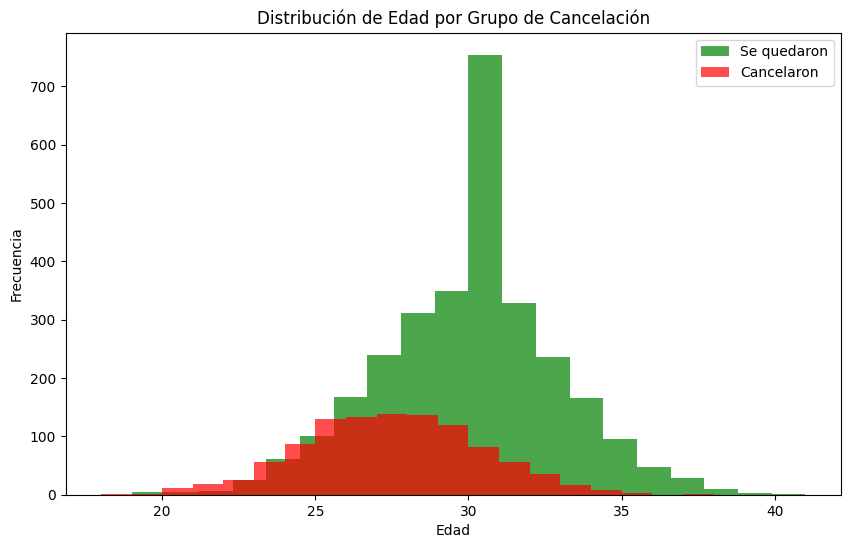

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(churn_0['Age'], bins=20, alpha=0.7, label='Se quedaron', color='green')
plt.hist(churn_1['Age'], bins=20, alpha=0.7, label='Cancelaron', color='red')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edad por Grupo de Cancelación')
plt.legend()
plt.show()

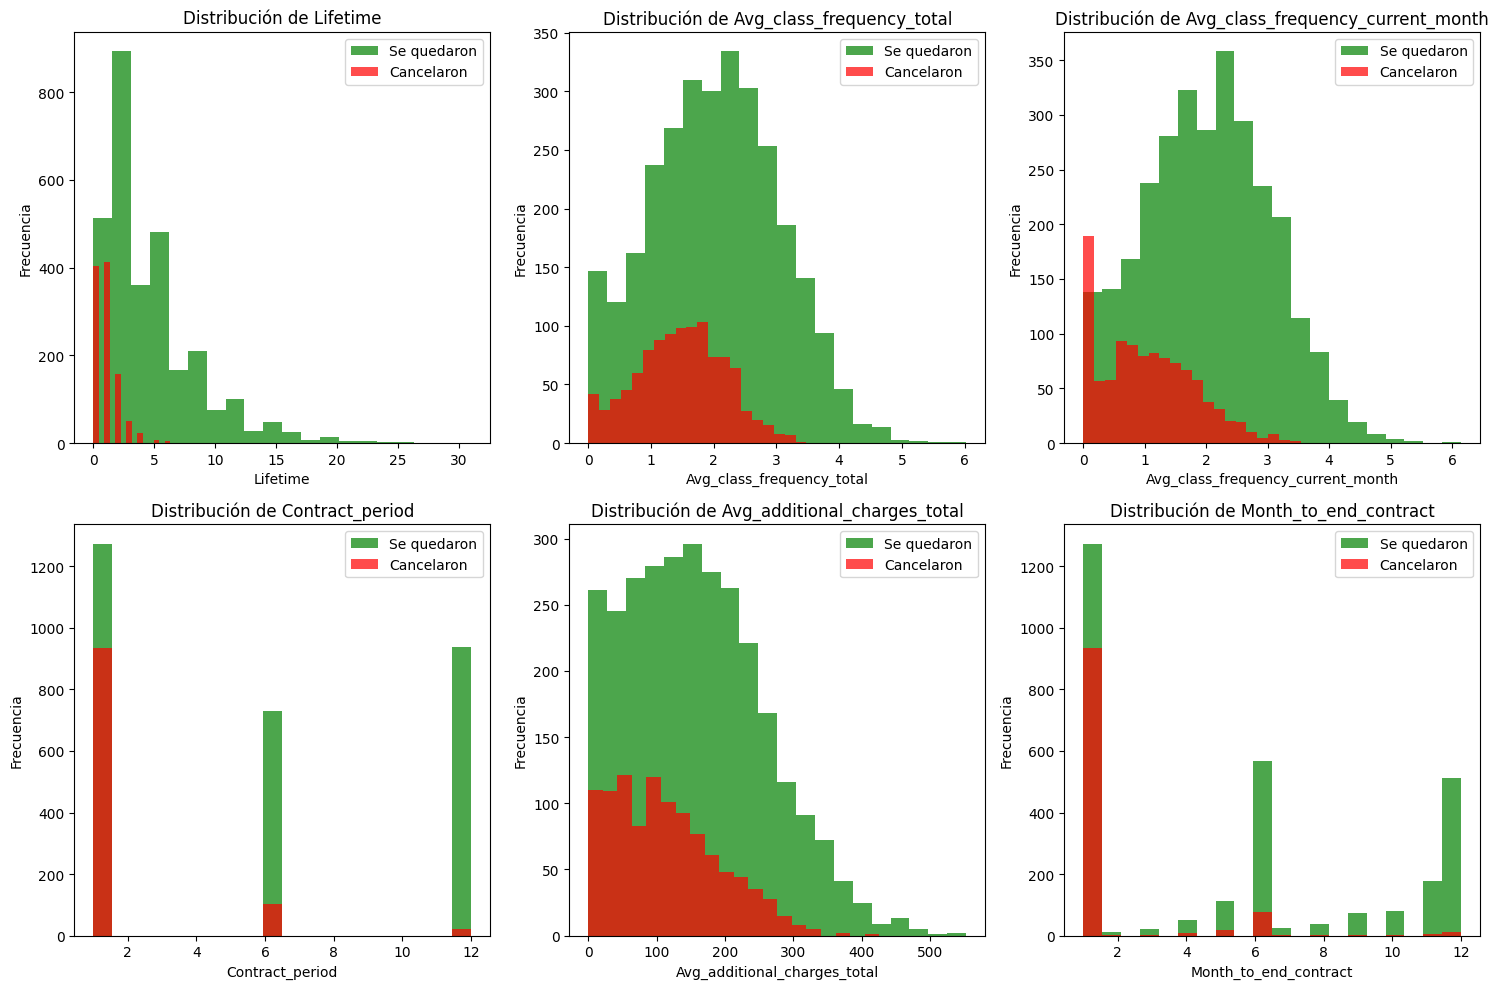

In [11]:
variables_numericas = ['Lifetime', 'Avg_class_frequency_total', 
                      'Avg_class_frequency_current_month', 'Contract_period',
                      'Avg_additional_charges_total', 'Month_to_end_contract']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel() 

for i, variable in enumerate(variables_numericas):
    axes[i].hist(churn_0[variable], bins=20, alpha=0.7, label='Se quedaron', color='green')
    axes[i].hist(churn_1[variable], bins=20, alpha=0.7, label='Cancelaron', color='red')
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_title(f'Distribución de {variable}')
    axes[i].legend()

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecho! Estas gráficas son muy claras para mostrar las diferencias entre cada variable de tu dataset
</div>

### Matriz de correlación.

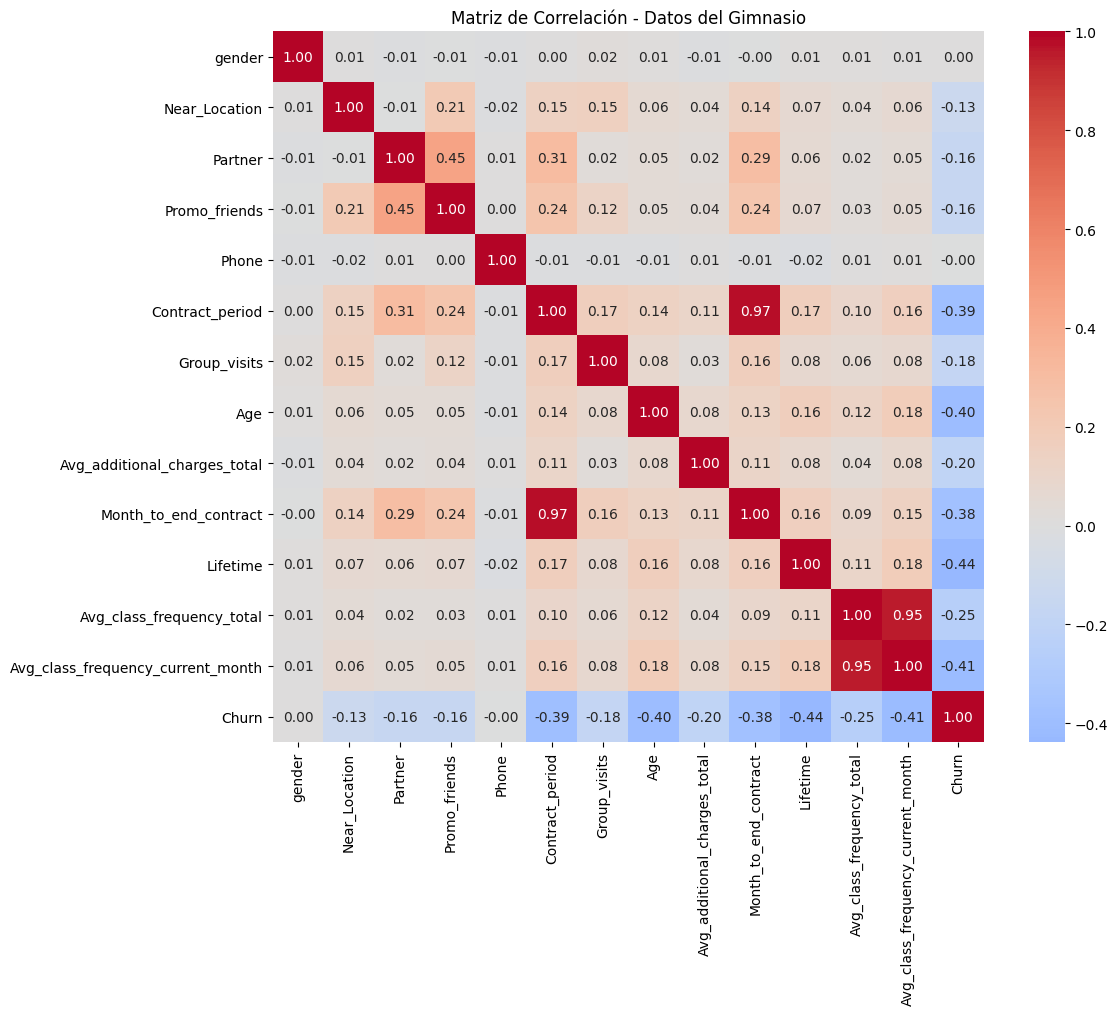

In [12]:
corr_gym = gym_churn.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_gym, 
            annot=True,           
            cmap='coolwarm',      
            center=0,             
            square=True,          
            fmt='.2f')            

plt.title('Matriz de Correlación - Datos del Gimnasio')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien mostrada la matriz de correlación! Solo ten en cuenta que no siempre correlación significa causalidad, puede que en algunos casos tengas variables altamente correlacionadas pero no necesariamente son causa una de la otra

### Modelo para predecir la cancelación de usuarios.

In [13]:
X = gym_churn.drop('Churn', axis=1)
y = gym_churn['Churn']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  
    random_state=42,  
    stratify=y  
)

In [15]:
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [16]:
random_forest_model = RandomForestClassifier(random_state=42, n_estimators=100)
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
y_pred_logistic = logistic_model.predict(X_test)
y_pred_forest = random_forest_model.predict(X_test)

In [18]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)

print("REGRESIÓN LOGÍSTICA")
print(f"Exactitud (Accuracy): {accuracy_logistic:.4f}")
print(f"Precisión (Precision): {precision_logistic:.4f}")
print(f"Recall: {recall_logistic:.4f}")

REGRESIÓN LOGÍSTICA
Exactitud (Accuracy): 0.9237
Precisión (Precision): 0.8756
Recall: 0.8302


In [19]:
accuracy_forest = accuracy_score(y_test, y_pred_forest)
precision_forest = precision_score(y_test, y_pred_forest)
recall_forest = recall_score(y_test, y_pred_forest)

print("RANDOM FOREST")
print(f"Exactitud (Accuracy): {accuracy_forest:.4f}")
print(f"Precisión (Precision): {precision_forest:.4f}")
print(f"Recall: {recall_forest:.4f}")

RANDOM FOREST
Exactitud (Accuracy): 0.9275
Precisión (Precision): 0.8850
Recall: 0.8349


##### Podemos ver que RANDOM FOREST es el modelo más preciso, ya que tiene mejores métricas; es bueno para evitar falsas alarmas, detecta clientes en riesgo y, sobre todo, es más preciso.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo! Obtuviste resultados muy buenos en el entrenamiento de tus modelos y realizaste el análisis adecuado a partir de los mismos
</div>

### Clústeres de usuarios/as.

In [20]:
scaler = StandardScaler()
numerical_features = ['Age', 'Avg_additional_charges_total', 'Lifetime']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345)

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler.fit(X_train[numerical_features])

X_train_scaled[numerical_features] = scaler.transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

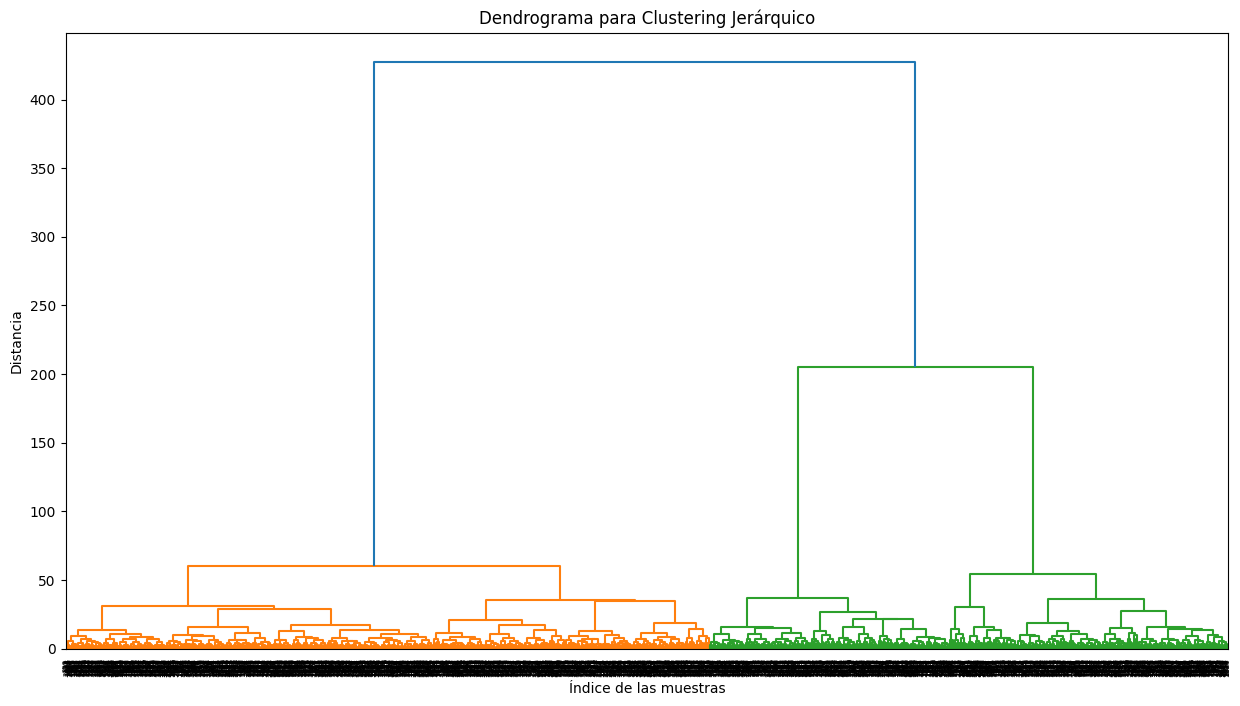

In [22]:
linkage_matrix = linkage(X_train_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix)
plt.title('Dendrograma para Clustering Jerárquico')
plt.xlabel('Índice de las muestras')
plt.ylabel('Distancia')
plt.show()

In [23]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

In [24]:
print("Distribución de clusters en el conjunto de entrenamiento:")
unique, counts = np.unique(train_clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} clientes")

print(f"Total de clientes en entrenamiento: {len(train_clusters)}")

Distribución de clusters en el conjunto de entrenamiento:
Cluster 0: 681 clientes
Cluster 1: 589 clientes
Cluster 2: 620 clientes
Cluster 3: 129 clientes
Cluster 4: 981 clientes
Total de clientes en entrenamiento: 3000


In [25]:
X_train_with_clusters = X_train_scaled.copy()
X_train_with_clusters['Cluster'] = train_clusters

cluster_means = X_train_with_clusters.groupby('Cluster').mean()
print(cluster_means)

           gender  Near_Location   Partner  Promo_friends     Phone  \
Cluster                                                               
0        0.527166       0.838473  0.359765       0.248164  0.897210   
1        0.504244       0.933786  0.723260       0.487267  0.899830   
2        0.517742       0.869355  0.554839       0.348387  0.893548   
3        0.519380       0.937984  0.728682       0.403101  0.953488   
4        0.486239       0.784913  0.364934       0.198777  0.908257   

         Contract_period  Group_visits       Age  \
Cluster                                            
0                    1.0      0.408223  0.248553   
1                   12.0      0.539898  0.192943   
2                    6.0      0.443548  0.102694   
3                   12.0      0.604651  0.251884   
4                    1.0      0.306830 -0.386413   

         Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
Cluster                                                        

##### Puedo observar que el clúster 0 tiene contratos de un mes y una alta frecuencia de clases, y los clientes suelen ser jóvenes, pero con compromiso a corto plazo.
##### El clúster 1 tiene contratos de 12 meses; muchos son parejas y tienen muchos meses de contrato.
##### Y el cluster 4 es el que tiene más miembros, pero tiene contratos de un mes, muy baja asistencia de clases y los clientes más jóvenes.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Bien hecho! Se nota claramente la segmentación entre los diferentes grupos ya que tienen un churn rate diferente
</div>

### Distribución de características.

In [26]:
X_train_original = X_train.copy()
X_train_original['Cluster'] = train_clusters

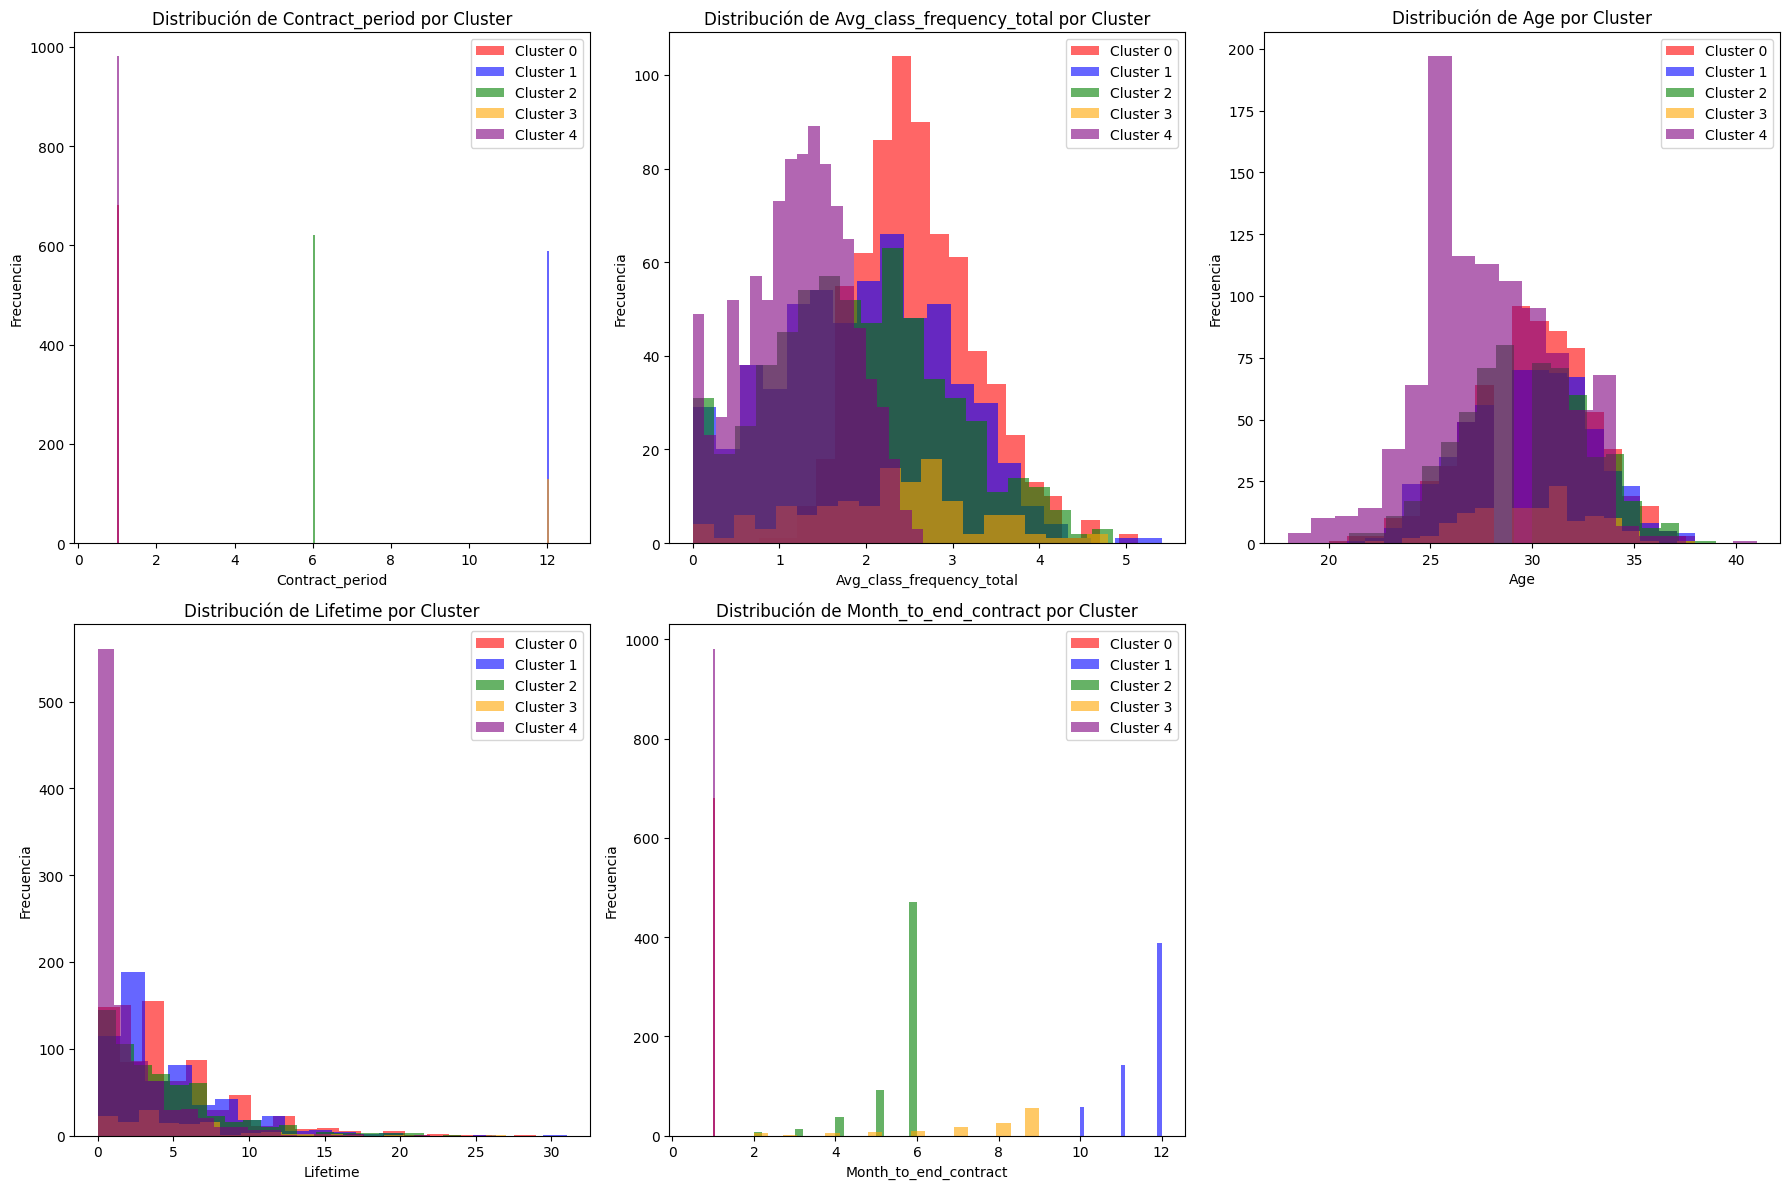

In [27]:
caracteristicas_clave = ['Contract_period', 'Avg_class_frequency_total', 
                        'Age', 'Lifetime', 'Month_to_end_contract']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

colores = ['red', 'blue', 'green', 'orange', 'purple']

for i, caracteristica in enumerate(caracteristicas_clave):
    for cluster in range(5):
        datos_cluster = X_train_original[X_train_original['Cluster'] == cluster][caracteristica]
        axes[i].hist(datos_cluster, bins=20, alpha=0.6, 
                    label=f'Cluster {cluster}', color=colores[cluster])
    
    axes[i].set_xlabel(caracteristica)
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_title(f'Distribución de {caracteristica} por Cluster')
    axes[i].legend()

axes[5].remove()

plt.tight_layout()
plt.show()

##### Contract_period (Período de contrato) Los clústeres 0 y 4 están unidos por los contratos de un mes; los 1 y 3 están unidos por contratos de 12 meses y, por último, el clúster 2 está en 6 meses.

##### Avg_class_frequency_total (Frecuencia de clases) El cluster o tiene alta frecuencia y el cluster morado tiene una muy baja; ambos tienen contratos cortos, pero comportamientos opuestos.

##### Age (Edad) El clúster morado tiene a los más jóvenes; los demás tienen una distribución más amplia.

##### Lifetime (Tiempo como Cliente) El cluster morado tiene los clientes mas nuevos el rojo tambien pero tiene clientes mas establecidos.

##### Lo mas interesante es que el cluster 0 y 4 son parecidos en contratos pero el 0 tiene usuarios intensivos y el 4 pasivos.

### Cálculo de tasas de cancelación.

In [28]:
datos_cluster_churn = pd.DataFrame({
    'Cluster': train_clusters,
    'Churn': y_train
})

print("Primeros registros:")
print(datos_cluster_churn.head())

Primeros registros:
      Cluster  Churn
2208        1      0
3079        0      0
1855        4      1
808         0      0
664         4      1


In [29]:
tasa_cancelacion = datos_cluster_churn.groupby('Cluster')['Churn'].agg(['count', 'sum', 'mean'])
tasa_cancelacion.columns = ['Total_Clientes', 'Cancelaciones', 'Tasa_Cancelacion']

print("Tasa de cancelación por cluster:")
print(tasa_cancelacion)

Tasa de cancelación por cluster:
         Total_Clientes  Cancelaciones  Tasa_Cancelacion
Cluster                                                 
0                   681             83          0.121880
1                   589             15          0.025467
2                   620             74          0.119355
3                   129              1          0.007752
4                   981            626          0.638124


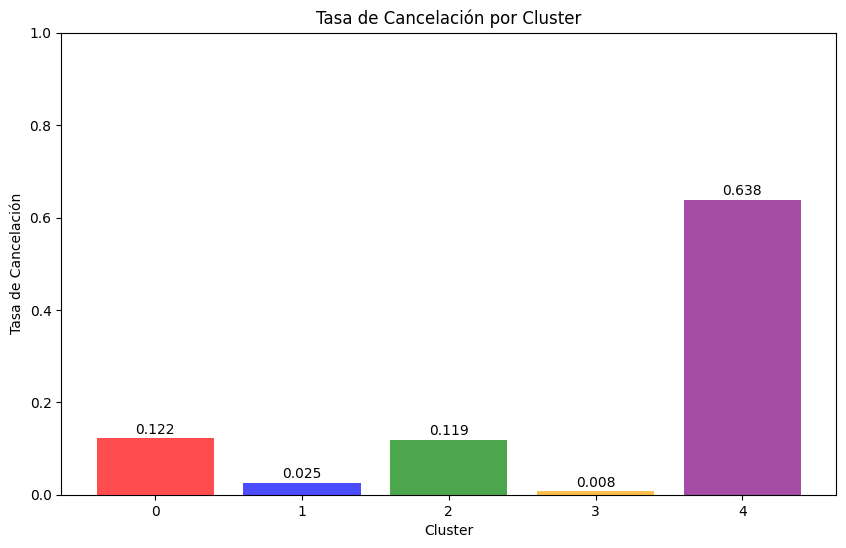

In [30]:
plt.figure(figsize=(10, 6))
plt.bar(tasa_cancelacion.index, tasa_cancelacion['Tasa_Cancelacion'], 
        color=['red', 'blue', 'green', 'orange', 'purple'], alpha=0.7)
plt.xlabel('Cluster')
plt.ylabel('Tasa de Cancelación')
plt.title('Tasa de Cancelación por Cluster')
plt.ylim(0, 1)

for i, v in enumerate(tasa_cancelacion['Tasa_Cancelacion']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.show()

### Conclusión y sugerencias.

##### Después del analisis de las cancelaciones podemos ver que el cluster 4 es el mas problematico ya que tiene los usuarios mas juvenes y la tasa de cancelacion mas alta y lo mas preocupante es que este cluster es el mas grande, podemos sugerir mucho en este cluster buscar insentivar a personas mayores a la inscripcion y buscar la permanencia después del primer mes podemos realisar una campaña de arketing para peronas de mas de 30 de años y para las menores de 30 un descuento por permanecer mas de un mes, los demás clusters son mas solidos en general solo hay que obsrvar la diferencia entre el mas conflictivo y los demás pero aun asi podemos sugerir cosas para estos tal vez promociones por lealtad o obsequios por parte de la administracion ademas de una oferta para que traigan a sus conocidos al gym con promociones para ellos y los nuevos usuarios.

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo, manejaste muy bien los datos previo al entrenamiento de tus modelos y analizaste muy bien los resultados.
    
Planteaste muy buenas conclusiones en base a los datos de tu análisis, un buen análisis siempre debe venir acompañado de recomendaciones que ayuden a la toma de decisiones que en este caso haz planteado sugerencias muy buenas en cuanto a los diferentes tipos de usuarios obtenidos.
    
    
Saludos!
</div>